# Multiaxial Concrete

{download}`Download <material-0005.ipynb>`

In [1]:

import xara
from xara.units.si import GPa, MPa

E  = 26*GPa
Fc = 15*MPa
Ft =  1*MPa
nu = 0.2

ec = 2.0*Fc/E
Gt = 0.073*Fc**0.18
Gc = 2.0*Gt*(Fc/Ft)**2

materials = [
    xara.TriaxialMaterial("FariaPlasticDamage",
        E=E, 
        nu = nu,
        Fc = Fc,
        Ft = Ft,
        beta=0.590,
        Ap=0.05, An=3, Bn=0.7
    ),
    xara.TriaxialMaterial("FariaPlasticDamage",
        E=E, 
        nu = nu,
        Fc = Fc,
        Ft = Ft,
        beta=0.590,
        Ap=2.5, An=3, Bn=0.75
    ),
    # xara.TriaxialMaterial("DruckerPrager",
    #     E=E,
    #     nu = nu,
    #     Fy = Fc,
    #     Fsat=1.2*Fc,
    # )
]

## Analysis

In [2]:

import numpy as np
n = 40
strains = [
    *np.linspace(0, -0.0025, n),
    *np.linspace(-0.0025, -0.001, n),
    *np.linspace(-0.001, -0.0035, n),
    *np.linspace(-0.0035, -0.0017, n),
    *np.linspace(-0.0017, -0.006, n),
]

def strain_test(mat):
    tau, sig, gam, eps = [], [], [], []

    # Create a temporary material to perform the test
    with mat as tmp:
        for eps_zz in strains:
            # Voigt order: [xx, yy, zz, xy, xz, yz]
            e0 = -nu*eps_zz
            strain = (e0, e0, eps_zz, 0.0, 0.0, 0.0)
            stress = tmp.getStress(strain, commit=True)

            sig.append(-stress[2])
            tau.append( stress[4])
            eps.append(-strain[2])
            gam.append( strain[4])

    return tau, sig, gam, eps


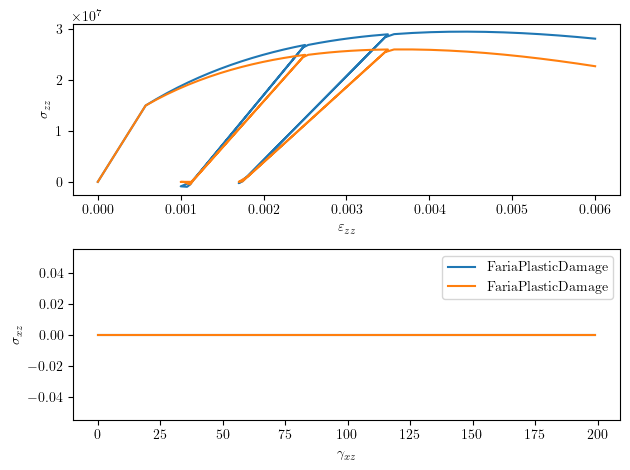

In [3]:


import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1)

for material in materials:

    tau, sig, gam, eps = strain_test(material)
    ax[0].plot(eps, sig)
    ax[1].plot(tau, label=material.type)


ax[1].set_ylabel(r'$\sigma_{xz}$')
ax[1].set_xlabel(r'$\gamma_{xz}$')
ax[0].set_ylabel(r'$\sigma_{zz}$')
ax[0].set_xlabel(r'$\varepsilon_{zz}$')
ax[1].legend()
plt.tight_layout()

### Stress test

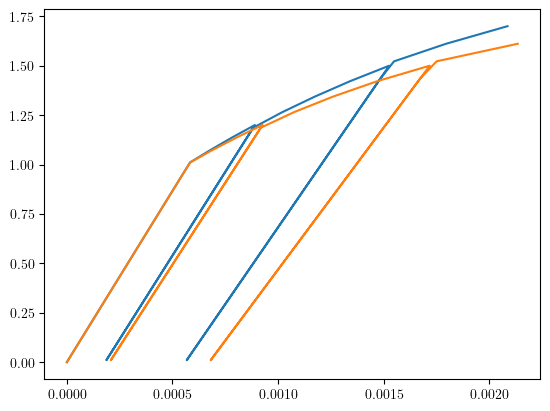

In [4]:
def stress_test(material):
    n = 20
    stress_history = [
        *np.linspace(0, -1.2*Fc, n),
        *np.linspace(-1.2*Fc, -0.01*Fc, n),
        *np.linspace(-0.01*Fc, -1.5*Fc, n),
        *np.linspace(-1.5*Fc, -0.01*Fc, n),
        *np.linspace(-0.01*Fc, -1.7*Fc, n),
    ]
    e = []
    s = []

    # Create a temporary material instance to run the test
    with material as tmp:
        for s_zz in stress_history:
            try:
                tmp.update(stress=[0.0, 0.0, s_zz, 0.0, 0.0, 0.0], commit=True)
            except:
                break
            e.append(-tmp.getStrain()[2])
            s.append(-s_zz/Fc)
    return e, s


fig, ax = plt.subplots()
for material in materials:
    e, s = stress_test(material)
    ax.plot(e, s, label=material.type)


## References
